In [57]:
import pandas as pd
import os
from pathlib import Path
from autoslo.filesystem.structured_log import StructuredLog

# Do not use scientific notation for pandas dataframes.
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

from autoslo.config.component_configs import SloResolverConfig, SloObjectiveConfig
from autoslo.slo.slo_resolver import SloResolver
from autoslo.slo.slo_objective import SloObjective

In [4]:
run_id = '1780293909869'

In [6]:
log = StructuredLog.load(run_id)
df = log.df

In [58]:
slo_resolver = SloResolver(SloResolverConfig.from_run_id(run_id))
slo_objective = SloObjective(SloObjectiveConfig.from_run_id(run_id))

In [10]:
dfrq = df[df['query_id'].notna()]
dfrq = dfrq[~dfrq['query_id'].str.startswith('fwd')]

In [11]:
dfrq['query_id'].nunique()

1392

In [21]:
dfrq.head()

,wall_clock_s,rel_time_s,source,event_type,query_id,query_text_id,cluster_name,details
4,1.780294e+09,0.007425,WorkloadRunner,arrival,204510,ext_tpcds1000#009#003,,
5,1.780294e+09,0.008417,QueryRouter,routing_score,204510,ext_tpcds1000#009#003,autoslo-8-1780293909869-0,"{""latency_s_for_routing"": ""24.314575"", ""slo_vi..."
6,1.780294e+09,0.008417,QueryRouter,routing,204510,ext_tpcds1000#009#003,autoslo-8-1780293909869-0,"{""latency_s_for_routing"": ""24.314575"", ""slo_vi..."
7,1.780294e+09,0.010335,WorkloadRunner,query_routed,204510,ext_tpcds1000#009#003,autoslo-8-1780293909869-0,"{""latency_s"": ""24.314575""}"
8,1.780294e+09,0.011090,WorkloadRunner,query_execution_start,204510,ext_tpcds1000#009#003,autoslo-8-1780293909869-0,


In [31]:
dfrq_core = dfrq[~dfrq['event_type'].isin(['routing_score', 'latency_update'])]
dfrq_core.shape

(8352, 8)

In [35]:
dfrq_core.head(10)

,wall_clock_s,rel_time_s,source,event_type,query_id,query_text_id,cluster_name,details
4,1.780294e+09,0.007425,WorkloadRunner,arrival,204510,ext_tpcds1000#009#003,,
6,1.780294e+09,0.008417,QueryRouter,routing,204510,ext_tpcds1000#009#003,autoslo-8-1780293909869-0,"{""latency_s_for_routing"": ""24.314575"", ""slo_vi..."
7,1.780294e+09,0.010335,WorkloadRunner,query_routed,204510,ext_tpcds1000#009#003,autoslo-8-1780293909869-0,"{""latency_s"": ""24.314575""}"
8,1.780294e+09,0.011090,WorkloadRunner,query_execution_start,204510,ext_tpcds1000#009#003,autoslo-8-1780293909869-0,
9,1.780294e+09,14.399479,WorkloadRunner,arrival,217123,ext_tpcds1000#009#003,,
11,1.780294e+09,14.400337,QueryRouter,routing,217123,ext_tpcds1000#009#003,autoslo-8-1780293909869-0,"{""latency_s_for_routing"": ""37.328804"", ""slo_vi..."
12,1.780294e+09,14.440750,WorkloadRunner,query_routed,217123,ext_tpcds1000#009#003,autoslo-8-1780293909869-0,"{""latency_s"": ""37.328804""}"
14,1.780294e+09,14.441368,WorkloadRunner,query_execution_start,217123,ext_tpcds1000#009#003,autoslo-8-1780293909869-0,
15,1.780294e+09,57.328475,WorkloadRunner,query_execution_finish,204510,ext_tpcds1000#009#003,autoslo-8-1780293909869-0,"{""latency_s"": 57.31738495826721}"
16,1.780294e+09,57.329766,WorkloadRunner,completion,204510,ext_tpcds1000#009#003,autoslo-8-1780293909869-0,"{""success"": true}"


In [38]:
# For each unique query_id, pivot the event_type and list the wall_clock_s for each event_type. 
# This will give us a breakdown of the time spent on each event_type for each query_id.
dfrq_pivot = dfrq_core.pivot_table(index='query_id', columns='event_type', values='wall_clock_s')
dfrq_pivot = dfrq_pivot[['arrival', 'routing', 'query_routed', 'query_execution_start', 'query_execution_finish', 'completion']]
dfrq_pivot.head()

event_type,arrival,routing,query_routed,query_execution_start,query_execution_finish,completion
query_id,,,,,,
173857,1.780300e+09,1.780300e+09,1.780300e+09,1.780300e+09,1.780302e+09,1.780302e+09
173858,1.780305e+09,1.780305e+09,1.780305e+09,1.780305e+09,1.780305e+09,1.780305e+09
173944,1.780304e+09,1.780304e+09,1.780304e+09,1.780304e+09,1.780304e+09,1.780304e+09
173945,1.780304e+09,1.780304e+09,1.780304e+09,1.780304e+09,1.780304e+09,1.780304e+09
173946,1.780299e+09,1.780299e+09,1.780299e+09,1.780299e+09,1.780299e+09,1.780299e+09


In [40]:
# Now calculate differences between successive columns to get the time spent on each phase of the query processing.
dfrq_pivot_diff = dfrq_pivot.diff(axis=1)
dfrq_pivot_diff.describe()

event_type,arrival,routing,query_routed,query_execution_start,query_execution_finish,completion
count,0.0,1392.000000,1392.000000,1392.000000,1392.000000,1392.000000
mean,NaN,0.924901,0.000876,0.009743,1149.646393,0.001057
std,NaN,1.113951,0.002869,0.013736,1298.096706,0.001831
min,NaN,0.002320,0.000085,0.000619,0.354869,0.000213
25%,NaN,0.142853,0.000514,0.001931,159.489147,0.000658
50%,NaN,0.369971,0.000738,0.006717,486.545560,0.000730
75%,NaN,1.369422,0.000932,0.011959,2066.062869,0.000774
max,NaN,5.133191,0.099630,0.272665,3607.062745,0.016335


In [44]:
# Some queries seem to take very long to route. Add a column to dfrq_pivot with
# a count of the "routing_score" entries for each query_id from dfrq.
dfrq_pivot_2 = dfrq_pivot[['arrival', 'query_routed']].copy()
dfrq_pivot_2['routing_score_count'] = dfrq[dfrq['event_type'] == 'routing_score'].groupby('query_id').size()
dfrq_pivot_2['routing_duration_s'] = dfrq_pivot_diff['routing']
dfrq_pivot_2.head()

event_type,arrival,query_routed,routing_score_count,routing_duration_s
query_id,,,,
173857,1.780300e+09,1.780300e+09,4,0.037161
173858,1.780305e+09,1.780305e+09,11,0.686466
173944,1.780304e+09,1.780304e+09,11,0.361480
173945,1.780304e+09,1.780304e+09,11,0.957732
173946,1.780299e+09,1.780299e+09,2,0.011137


In [49]:
dfrq[dfrq['event_type'] == 'routing_score'].groupby('query_id').size().describe()

count    1392.000000
mean        9.260776
std         2.920753
min         1.000000
25%         9.000000
50%        11.000000
75%        11.000000
max        11.000000
dtype: float64

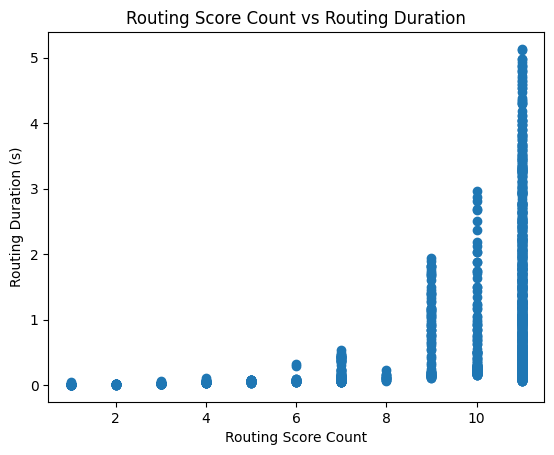

In [45]:
# Plot a scatter plot of routing_score_count vs routing_duration_s to see if 
# there is a correlation between the number of routing_score events and the routing duration.
import matplotlib.pyplot as plt

plt.scatter(dfrq_pivot_2['routing_score_count'], dfrq_pivot_2['routing_duration_s'])
plt.xlabel('Routing Score Count')
plt.ylabel('Routing Duration (s)')
plt.title('Routing Score Count vs Routing Duration')
plt.show()

In [55]:
df[df['query_id'] == '173858']

,wall_clock_s,rel_time_s,source,event_type,query_id,query_text_id,cluster_name,details
55417,1780304984.609,10717.158,WorkloadRunner,arrival,173858,ext_tpcds1000#041#002,,
55472,1780304985.292,10717.615,QueryRouter,routing_score,173858,ext_tpcds1000#041#002,autoslo-8-1780293909869-0,"{""latency_s_for_routing"": ""2.9103887"", ""slo_violation"": 0.9161073825503355, ""cost"": 23.31791666666667, ""cache_risk"": 0.0}"
55473,1780304985.292,10717.615,QueryRouter,routing_score,173858,ext_tpcds1000#041#002,autoslo-4-1780293909869-1,"{""latency_s_for_routing"": ""2.03005"", ""slo_violation"": 0.9060402684563759, ""cost"": 23.299583333333338, ""cache_risk"": 0.0}"
55474,1780304985.293,10717.615,QueryRouter,routing_score,173858,ext_tpcds1000#041#002,autoslo-4-1780293909869-2,"{""latency_s_for_routing"": ""2.1190388"", ""slo_violation"": 0.9060402684563759, ""cost"": 23.331250000000004, ""cache_risk"": 0.0}"
55475,1780304985.293,10717.615,QueryRouter,routing_score,173858,ext_tpcds1000#041#002,autoslo-4-1780293909869-3,"{""latency_s_for_routing"": ""2.3028557"", ""slo_violation"": 0.9026845637583892, ""cost"": 23.327916666666674, ""cache_risk"": 0.0}"
55476,1780304985.294,10717.615,QueryRouter,routing_score,173858,ext_tpcds1000#041#002,autoslo-4-1780293909869-4,"{""latency_s_for_routing"": ""2.7195017"", ""slo_violation"": 0.9026845637583892, ""cost"": 23.299583333333338, ""cache_risk"": 0.0}"
55477,1780304985.294,10717.615,QueryRouter,routing_score,173858,ext_tpcds1000#041#002,autoslo-4-1780293909869-5,"{""latency_s_for_routing"": ""3.3306732"", ""slo_violation"": 0.9026845637583892, ""cost"": 23.391666666666673, ""cache_risk"": 0.0}"
55478,1780304985.294,10717.615,QueryRouter,routing_score,173858,ext_tpcds1000#041#002,autoslo-4-1780293909869-6,"{""latency_s_for_routing"": ""3.3241014"", ""slo_violation"": 0.9093959731543624, ""cost"": 23.299583333333338, ""cache_risk"": 0.0}"
55479,1780304985.295,10717.615,QueryRouter,routing_score,173858,ext_tpcds1000#041#002,autoslo-4-1780293909869-7,"{""latency_s_for_routing"": ""3.3040562"", ""slo_violation"": 0.9093959731543624, ""cost"": 23.300000000000004, ""cache_risk"": 0.0}"
55480,1780304985.295,10717.615,QueryRouter,routing_score,173858,ext_tpcds1000#041#002,autoslo-4-1780293909869-8,"{""latency_s_for_routing"": ""3.8944354"", ""slo_violation"": 0.9060402684563759, ""cost"": 23.310833333333335, ""cache_risk"": 0.0}"


---

# Autoscaler

In [64]:
df[(df['source'] == 'Autoscaler') & (df['rel_time_s'] < 4000)]

,wall_clock_s,rel_time_s,source,event_type,query_id,query_text_id,cluster_name,details
379,1780297844.266,3576.684,Autoscaler,rpu_counterfactual,None,None,autoslo-4-hypothetical,"{""rpu"": 4, ""slo_violation"": 0.0, ""cost"": 1.8575000000000002, ""slo_threshold"": 0.1}"
470,1780297844.358,3576.684,Autoscaler,rpu_counterfactual,None,None,autoslo-8-hypothetical,"{""rpu"": 8, ""slo_violation"": 0.0, ""cost"": 2.1075, ""slo_threshold"": 0.1}"
561,1780297844.446,3576.684,Autoscaler,rpu_counterfactual,None,None,autoslo-16-hypothetical,"{""rpu"": 16, ""slo_violation"": 0.0, ""cost"": 2.6075, ""slo_threshold"": 0.1}"
654,1780297844.795,3576.684,Autoscaler,rpu_counterfactual,None,None,autoslo-32-hypothetical,"{""rpu"": 32, ""slo_violation"": 0.0, ""cost"": 3.1075, ""slo_threshold"": 0.1}"
655,1780297844.795,3576.684,Autoscaler,rpu_selection,None,None,autoslo-4-hypothetical,"{""rpu"": 4, ""slo_violation"": 0.0, ""cost"": 1.8575000000000002, ""slo_threshold"": 0.1}"
656,1780297844.795,3576.684,Autoscaler,spin_up_decision,None,None,,"{""rpu"": 4, ""reason"": ""num_queries_since_last_cluster_ready=36, slo_metric=SloMetric.BINARY, slo_metric_value=0.3333, slo_threshold=0.1000, slo_tightening_factor=0.6"", ""autoscaling_policy"": ""add_single_best_forward""}"


In [70]:
df.iloc[379:657]

,wall_clock_s,rel_time_s,source,event_type,query_id,query_text_id,cluster_name,details
379,1780297844.266,3576.684,Autoscaler,rpu_counterfactual,None,None,autoslo-4-hypothetical,"{""rpu"": 4, ""slo_violation"": 0.0, ""cost"": 1.8575000000000002, ""slo_threshold"": 0.1}"
380,1780297844.267,3936.684,Autoscaler.QueryRouter,routing_score,fwd-2:188680,ext_tpcds1000#093#003,autoslo-8-1780293909869-0,"{""latency_s_for_routing"": ""8.565762"", ""slo_violation"": 0.0, ""cost"": 1.1075000000000002, ""cache_risk"": 0.0}"
381,1780297844.267,3936.684,Autoscaler.QueryRouter,routing_score,fwd-2:188680,ext_tpcds1000#093#003,autoslo-8-hypothetical,"{""latency_s_for_routing"": ""8.565762"", ""slo_violation"": 0.0, ""cost"": 1.1075000000000002, ""cache_risk"": 0.0}"
382,1780297844.267,3936.684,Autoscaler.QueryRouter,routing,fwd-2:188680,ext_tpcds1000#093#003,autoslo-8-1780293909869-0,"{""latency_s_for_routing"": ""8.565762"", ""slo_violation"": 0.0, ""cost"": 1.1075000000000002, ""cache_risk"": 0.0}"
383,1780297844.271,3936.684,Autoscaler.QueryRouter,routing_score,fwd-2:207412,ext_tpcds1000#098#002,autoslo-8-1780293909869-0,"{""latency_s_for_routing"": ""8.11567"", ""slo_violation"": 0.5, ""cost"": 1.1075000000000002, ""cache_risk"": 0.0}"
...,...,...,...,...,...,...,...,...
652,1780297844.794,5016.684,Autoscaler.QueryRouter,routing_score,fwd-11:212333,ext_tpcds1000#003#001,autoslo-32-hypothetical,"{""latency_s_for_routing"": ""4.0400147"", ""slo_violation"": 0.0, ""cost"": 2.9075, ""cache_risk"": 0.0}"
653,1780297844.794,5016.684,Autoscaler.QueryRouter,routing,fwd-11:212333,ext_tpcds1000#003#001,autoslo-32-hypothetical,"{""latency_s_for_routing"": ""4.0400147"", ""slo_violation"": 0.0, ""cost"": 2.9075, ""cache_risk"": 0.0}"
654,1780297844.795,3576.684,Autoscaler,rpu_counterfactual,None,None,autoslo-32-hypothetical,"{""rpu"": 32, ""slo_violation"": 0.0, ""cost"": 3.1075, ""slo_threshold"": 0.1}"
655,1780297844.795,3576.684,Autoscaler,rpu_selection,None,None,autoslo-4-hypothetical,"{""rpu"": 4, ""slo_violation"": 0.0, ""cost"": 1.8575000000000002, ""slo_threshold"": 0.1}"
